In [9]:
from torchvision import datasets
from torchvision.transforms import transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader

In [10]:
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

full_train_data = datasets.CIFAR10(
    root="../data",
    download=False,
    train=True,
    transform=transform,
)

test_data = datasets.CIFAR10(
    root="../data", download=False, train=False, transform=transform
)

In [11]:
print("Full training set: ", len(full_train_data), "\nTesting set: ", len(test_data))

Full training set:  50000 
Testing set:  10000


In [12]:
train_size = 40000
val_size = 10000

train_data, val_data = random_split(full_train_data, [train_size, val_size])

print(
    "Train set: ",
    len(train_data),
    "\nVal set: ",
    len(val_data),
    "\nTest set: ",
    len(test_data),
)

Train set:  40000 
Val set:  10000 
Test set:  10000


In [13]:
train_loader = DataLoader(
    train_data, batch_size=64, shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

In [14]:
import torchvision.models as models

In [15]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

In [16]:
import torch.nn as nn

num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [17]:
import torch
import torch.optim as optim

In [18]:
device = torch.device("cuda")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Epoch 1/5
Train - Loss: 0.5839 Acc: 0.7974
Val   - Loss: 0.5105 Acc: 0.8354
-------------------------
Epoch 2/5
Train - Loss: 0.3371 Acc: 0.8831
Val   - Loss: 0.4199 Acc: 0.8606
-------------------------
Epoch 3/5
Train - Loss: 0.2421 Acc: 0.9174
Val   - Loss: 0.3529 Acc: 0.8827
-------------------------
Epoch 4/5
Train - Loss: 0.1673 Acc: 0.9415
Val   - Loss: 0.3727 Acc: 0.8819
-------------------------
Epoch 5/5
Train - Loss: 0.1289 Acc: 0.9553
Val   - Loss: 0.4102 Acc: 0.8826
-------------------------

OVERALL ACCURACY: 0.8873

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1000
           1       0.97      0.92      0.94      1000
           2       0.94      0.82      0.87      1000
           3       0.70      0.86      0.77      1000
           4       0.83      0.95      0.89      1000
           5       0.84      0.82      0.83      1000
           6       0.96      0.89      0.93      1000
      

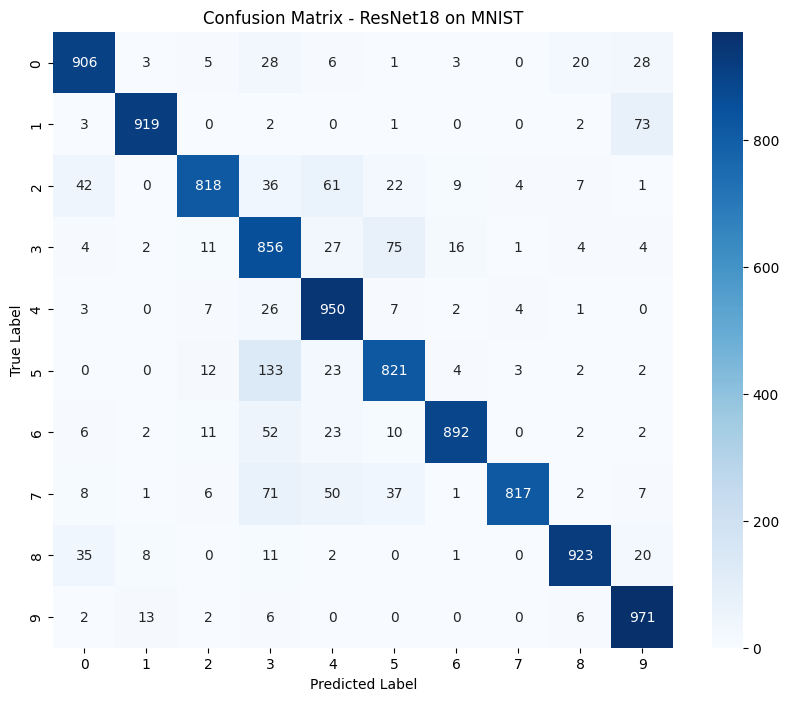

In [20]:
epochs = 5

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_corrects.double() / len(val_loader.dataset)

    # --- Print Epoch Metrics ---
    # Używamy f-stringów dla czytelności (4 miejsca po przecinku)
    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"Train - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    print(f"Val   - Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    print("-" * 25)  # Separator dla przejrzystości


# --- Final Test Phase ---
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Obliczanie metryk
accuracy = accuracy_score(all_labels, all_preds)
report = classification_report(
    all_labels, all_preds, target_names=[str(i) for i in range(10)]
)

print("\n" + "=" * 30)
print(f"OVERALL ACCURACY: {accuracy:.4f}")
print("=" * 30)
print("\nCLASSIFICATION REPORT:\n")
print(report)

# 3. Generowanie Macierzy Pomyłek (Heatmap)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)],
)
plt.title("Confusion Matrix - ResNet18 on MNIST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Epoch 1/10
Train - Loss: 0.0989 Acc: 0.9663
Val   - Loss: 0.3639 Acc: 0.8944
-------------------------
Epoch 2/10
Train - Loss: 0.0887 Acc: 0.9689
Val   - Loss: 0.3900 Acc: 0.8896
-------------------------
Epoch 3/10
Train - Loss: 0.0746 Acc: 0.9742
Val   - Loss: 0.3936 Acc: 0.8939
-------------------------
Epoch 4/10
Train - Loss: 0.0607 Acc: 0.9792
Val   - Loss: 0.4370 Acc: 0.8809
-------------------------
Epoch 5/10
Train - Loss: 0.0526 Acc: 0.9823
Val   - Loss: 0.4650 Acc: 0.8853
-------------------------
Epoch 6/10
Train - Loss: 0.0577 Acc: 0.9805
Val   - Loss: 0.4185 Acc: 0.8940
-------------------------
Epoch 7/10
Train - Loss: 0.0536 Acc: 0.9816
Val   - Loss: 0.4901 Acc: 0.8843
-------------------------
Epoch 8/10
Train - Loss: 0.0402 Acc: 0.9867
Val   - Loss: 0.4583 Acc: 0.8904
-------------------------
Epoch 9/10
Train - Loss: 0.0428 Acc: 0.9853
Val   - Loss: 0.4144 Acc: 0.8999
-------------------------
Epoch 10/10
Train - Loss: 0.0330 Acc: 0.9891
Val   - Loss: 0.4378 Acc: 0.

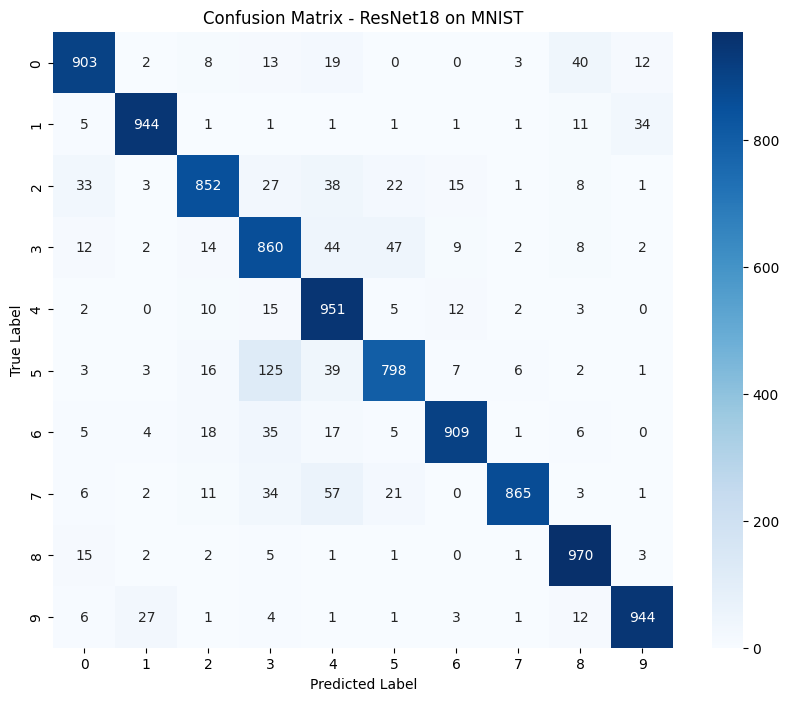

In [15]:
epochs = 10

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_corrects.double() / len(val_loader.dataset)

    # --- Print Epoch Metrics ---
    # Używamy f-stringów dla czytelności (4 miejsca po przecinku)
    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"Train - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    print(f"Val   - Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    print("-" * 25)  # Separator dla przejrzystości


# --- Final Test Phase ---
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Obliczanie metryk
accuracy = accuracy_score(all_labels, all_preds)
report = classification_report(
    all_labels, all_preds, target_names=[str(i) for i in range(10)]
)

print("\n" + "=" * 30)
print(f"OVERALL ACCURACY: {accuracy:.4f}")
print("=" * 30)
print("\nCLASSIFICATION REPORT:\n")
print(report)

# 3. Generowanie Macierzy Pomyłek (Heatmap)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[str(i) for i in range(10)],
    yticklabels=[str(i) for i in range(10)],
)
plt.title("Confusion Matrix - ResNet18 on MNIST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [17]:
from pathlib import Path

model_path = Path("../models/resnet18_cifar10_trained.pth")
torch.save(model.state_dict(), model_path)